In [55]:
# ============================================================
# 1. Import Required Libraries
# ============================================================

import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    mean_absolute_error,
    accuracy_score,
    confusion_matrix,
    classification_report
)

import seaborn as sns
import matplotlib.pyplot as plt

In [56]:
# ============================================================
# 2. Load the Dataset
# ============================================================

df = pd.read_csv('/kaggle/input/datasets/malakzidan19/car-datase/car data.csv')
df

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [57]:
# ============================================================
# 3. Explore the Dataset
# ============================================================

df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [58]:
df.shape

(301, 9)

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [60]:
df.nunique()

Car_Name          98
Year              16
Selling_Price    156
Present_Price    147
Kms_Driven       206
Fuel_Type          3
Seller_Type        2
Transmission       2
Owner              3
dtype: int64

In [61]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [62]:
# ============================================================
# 4. Select Features for Visualization
# ============================================================

features = ['Year', 'Present_Price', 'Kms_Driven']

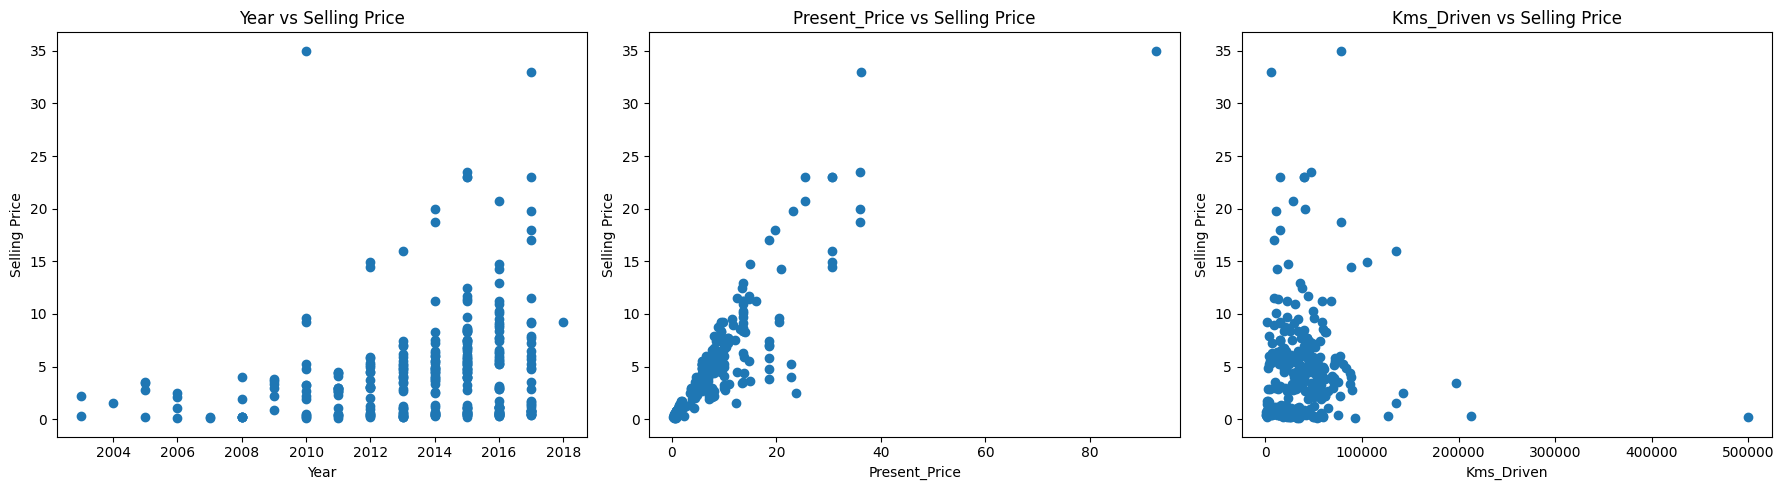

In [63]:
# ============================================================
# 5. Visualize Features vs Selling Price
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, feature in enumerate(features):
    axes[i].scatter(df[feature], df['Selling_Price'])
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Selling Price')
    axes[i].set_title(f'{feature} vs Selling Price')

plt.tight_layout()
plt.show()

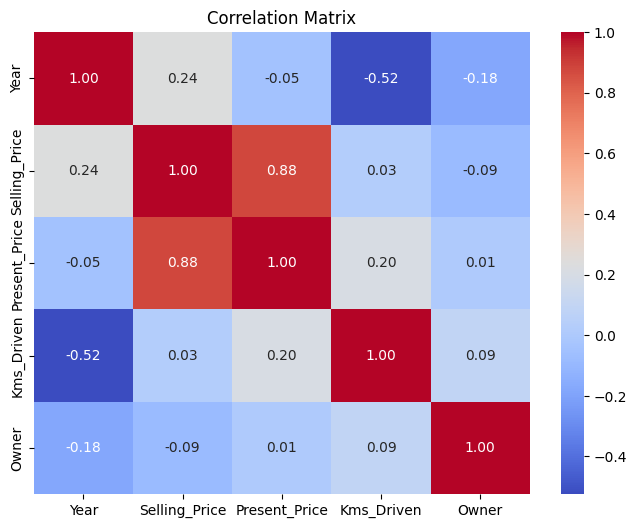

In [64]:
# ============================================================
# 6. Create the Correlation Matrix
# ============================================================

corr_matrix = df[['Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Owner']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Matrix')
plt.show()

In [65]:
# ============================================================
# 7. Prepare Data for Linear Regression
# ============================================================

linear_X = df[
    ['Year', 'Present_Price', 'Kms_Driven', 'Owner']
]
linear_y = df['Selling_Price']

In [66]:
# ============================================================
# 8. Split the Data into Training and Testing Sets
# ============================================================

linear_X_train, linear_X_test, linear_y_train, linear_y_test = train_test_split(
    linear_X,
    linear_y,
    test_size=0.2,
    random_state=42
)

In [67]:
# ============================================================
# 9. Train the Linear Regression Model
# ============================================================

linear_model = LinearRegression()

linear_model.fit(
    linear_X_train,
    linear_y_train
)

LinearRegression()

In [68]:
# ============================================================
# 10. Display Linear Regression Parameters
# ============================================================

print("Intercept:", linear_model.intercept_)
print("Coefficients:", linear_model.coef_)

Intercept: -848.8674377267627
Coefficients: [ 4.21976646e-01  5.16078190e-01 -8.55741965e-07 -1.14044373e+00]


In [69]:
# ============================================================
# 11. Make Predictions Using the Linear Regression Model
# ============================================================

linear_predictions = linear_model.predict(linear_X_test)

print(linear_predictions[:10])
print(linear_y_test.values[:10])

[ 2.11110638  8.84674696  4.94936351 -1.14863374 10.14153427  5.98266521
  2.15188862  1.4408292   2.10418146  6.08999593]
[ 0.35 10.11  4.95  0.15  6.95  7.45  1.1   0.5   0.45  6.  ]


In [70]:
# ============================================================
# 12. Evaluate the Linear Regression Model
# ============================================================

linear_mae = mean_absolute_error(
    linear_y_test,
    linear_predictions
)

print("MAE:", linear_mae)

MAE: 1.3939672804921246


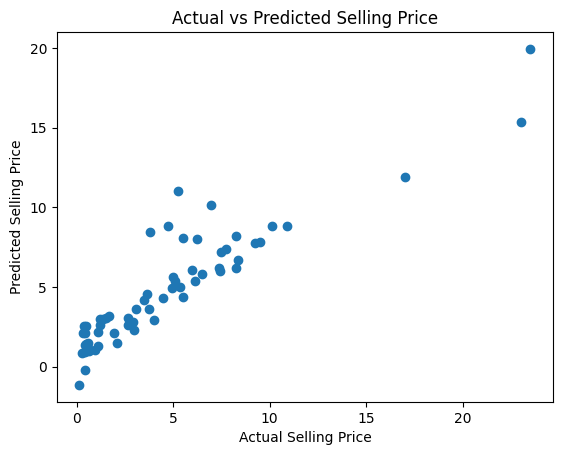

In [71]:
# ============================================================
# 13. Compare Actual vs Predicted Selling Prices
# ============================================================

plt.scatter(
    linear_y_test,
    linear_predictions
)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Selling Price")

plt.show()

In [72]:
# ============================================================
# 14. Predict the Selling Price of a New Car
# ============================================================

predicted_price = linear_model.predict([[2017, 8.5, 15000, 0]])

print("Predicted Selling Price:", predicted_price[0])

Predicted Selling Price: 6.633284754424039


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [73]:
# ============================================================
# 15. Create the Classification Target
# ============================================================

median_price = df['Selling_Price'].median()

df['Expensive'] = (df['Selling_Price'] >= median_price).astype(int)

df[['Selling_Price', 'Expensive']].head()

,Selling_Price,Expensive
0,3.35,0
1,4.75,1
2,7.25,1
3,2.85,0
4,4.60,1


In [74]:
# ============================================================
# 16. Prepare Data for Logistic Regression
# ============================================================

logistic_X = df[
    ['Year', 'Present_Price', 'Kms_Driven', 'Owner']
]

logistic_y = df['Expensive']

In [75]:
# ============================================================
# 17. Split the Data into Training and Testing Sets
# ============================================================

logistic_X_train, logistic_X_test, logistic_y_train, logistic_y_test = train_test_split(
    logistic_X,
    logistic_y,
    test_size=0.2,
    random_state=42,
    stratify=logistic_y
)

In [76]:
# ============================================================
# 18. Train the Logistic Regression Model
# ============================================================

logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit( logistic_X_train , logistic_y_train )

LogisticRegression(max_iter=1000)

In [77]:
# ============================================================
# 19. Make Predictions Using the Logistic Regression Model
# ============================================================

logistic_predictions = logistic_model.predict(logistic_X_test)

print(logistic_predictions[:10])
print(logistic_y_test.values[:10])

[0 0 0 0 0 0 1 0 1 0]
[0 0 0 0 0 0 1 0 1 0]


In [78]:
# ============================================================
# 20. Evaluate the Logistic Regression Model
# ============================================================

logistic_accuracy = accuracy_score(
    logistic_y_test,
    logistic_predictions
)

print("Accuracy:", logistic_accuracy)

Accuracy: 0.9508196721311475


In [79]:
# ============================================================
# 21. Classify a New Car
# ============================================================

new_car = pd.DataFrame({
    'Year': [2017],
    'Present_Price': [8.5],
    'Kms_Driven': [15000],
    'Owner': [0]
})

logistic_prediction = logistic_model.predict(new_car)

if logistic_prediction[0] == 1:
    print("The car is Expensive 🚗")
else:
    print("The car is Not Expensive 🚗")

The car is Expensive 🚗
